# Task 3: Retrieval-Augmented Generative Model Performance Comparison (No Reranker)

This notebook evaluates a retrieval-augmented generation pipeline using the retrieval-side choices carried forward from Task 1 and the Ollama generator setup from Task 2.

Fixed retrieval architecture:
- sentence chunking with 3 sentences and overlap 1
- HNSW first-stage retrieval
- no reranker

Generator comparison:
- qwen2.5:1.5b
- phi3:mini

Evaluation:
- exact_match
- transformer_match

Reporting:
- overall scores
- stratified scores by `DifficultyFromAnswerer` for `easy`, `medium`, and `hard`

The notebook answers the first major end-to-end design question of the project: once retrieval is added, how much does answer quality improve, and which generator should be carried forward before reranker selection begins?


In [1]:
import os
import sys
import time
from pathlib import Path
from typing import List, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from openai import OpenAI


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("textwave exists:", (PROJECT_ROOT / "textwave").exists())

Project root: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main
textwave exists: True


In [3]:
from textwave.modules.extraction.preprocessing import DocumentProcessing
from textwave.modules.extraction.embedding import Embedding
from textwave.modules.utils.metrics import Matching
from hnsw import FaissHNSW


In [4]:
QUESTIONS_PATH= PROJECT_ROOT / "textwave" / "qa_resources" / "question.tsv"

CORPUS_DIR = PROJECT_ROOT / "textwave" / "storage"
RESULTS_DIR = PROJECT_ROOT / "analysis" / "results" / "task3_rag_hnsw_no_reranker"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
CHUNKING_CONFIG = {"num_sentences": 3, "overlap_size": 1}
HNSW_CONFIG = {"M": 32, "efConstruction": 120, "metric": "euclidean"}

# Put qwen first since it was stronger in Task 2.
GENERATOR_MODELS = ["qwen2.5:1.5b", "phi3:mini"]

OLLAMA_BASE_URL = "http://localhost:11434/v1"
OLLAMA_API_KEY = "ollama"
TEMPERATURE = 0.2
TOP_K_CONTEXT = 5

# For quick testing, set this to a small number like 20.
MAX_QUESTIONS = None

print("Questions path:", QUESTIONS_PATH)
print("Corpus dir:", CORPUS_DIR)
print("Results dir:", RESULTS_DIR)
print("Chunking config:", CHUNKING_CONFIG)
print("HNSW config:", HNSW_CONFIG)
print("Models:", GENERATOR_MODELS)


Questions path: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\textwave\qa_resources\question.tsv
Corpus dir: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\textwave\storage
Results dir: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task3_rag_hnsw_no_reranker
Chunking config: {'num_sentences': 3, 'overlap_size': 1}
HNSW config: {'M': 32, 'efConstruction': 120, 'metric': 'euclidean'}
Models: ['qwen2.5:1.5b', 'phi3:mini']


## Load and clean the evaluation set

We keep only rows that have a valid question, gold answer, and source article id, because those are required for both retrieval and answer scoring.


In [5]:
def normalize_article_id(value: str) -> str:
    value = Path(str(value)).name
    for suffix in [".txt.clean", ".clean", ".txt"]:
        if value.endswith(suffix):
            value = value[:-len(suffix)]
    return value

def safe_text(x) -> str:
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return x if isinstance(x, str) else str(x)

ANSWER_COLUMN_CANDIDATES = [
    "Answer", "Answers", "answer", "answers",
    "GoldAnswer", "gold_answer", "ExpectedAnswer", "expected_answer"
]

questions_df = pd.read_csv(QUESTIONS_PATH, sep="\t")
ANSWER_COLUMN = next((col for col in ANSWER_COLUMN_CANDIDATES if col in questions_df.columns), None)
if ANSWER_COLUMN is None:
    raise KeyError("Could not find an answer column in question.tsv.")

corpus_files = sorted(CORPUS_DIR.glob("*.clean"))
available_article_ids = {normalize_article_id(path.name) for path in corpus_files}

questions_df["question_text"] = questions_df["Question"].apply(safe_text)
questions_df["gold_answer"] = questions_df[ANSWER_COLUMN].apply(safe_text)
questions_df["article_id_norm"] = questions_df["ArticleFile"].apply(safe_text).map(normalize_article_id)
questions_df["difficulty"] = questions_df["DifficultyFromAnswerer"].apply(safe_text).str.strip().str.lower()

questions_df = questions_df[
    (questions_df["question_text"].str.strip() != "") &
    (questions_df["gold_answer"].str.strip() != "") &
    (questions_df["article_id_norm"].str.strip() != "") &
    (questions_df["article_id_norm"].isin(available_article_ids))
].copy()

if MAX_QUESTIONS is not None:
    questions_df = questions_df.head(MAX_QUESTIONS).copy()

questions_df = questions_df.reset_index(drop=True)
questions_df["row_id"] = np.arange(len(questions_df))

print("Questions kept for evaluation:", len(questions_df))
print("Difficulty counts:")
display(questions_df["difficulty"].value_counts(dropna=False).rename_axis("difficulty").reset_index(name="rows"))
display(questions_df.head())


Questions kept for evaluation: 838
Difficulty counts:


,difficulty,rows
0,easy,322
1,medium,304
2,hard,181
3,too hard,25
4,too easy,6


,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile,question_text,gold_answer,article_id_norm,difficulty,row_id
0,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4,Was Abraham Lincoln the sixteenth President of...,yes,S08_set3_a4,easy,0
1,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4,Was Abraham Lincoln the sixteenth President of...,Yes.,S08_set3_a4,easy,1
2,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4,Did Lincoln sign the National Banking Act of 1...,yes,S08_set3_a4,medium,2
3,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4,Did Lincoln sign the National Banking Act of 1...,Yes.,S08_set3_a4,easy,3
4,Abraham_Lincoln,Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4,Did his mother die of pneumonia?,no,S08_set3_a4,medium,4


## Build the sentence-based chunk table

This uses the selected chunking strategy:
- 3 sentences per chunk
- overlap of 1 sentence

This step initializes the three main pipeline components used in this notebook: document processing for chunk creation, embedding for vector retrieval, and matching for answer evaluation. 

We build the retrieval unit table by applying the selected sentence-based chunking strategy to every source article in the collection. Each resulting row corresponds to one chunk and records not only the chunk text, but also its source article, its position within that article, and the chunking parameters used to create it. The resulting `chunk_df` is therefore the core retrieval index table for the no-reranker RAG experiment: it defines the textual units that will later be embedded, retrieved, and passed to generation as context.


In [6]:
processor = DocumentProcessing()
embedder = Embedding(EMBEDDING_MODEL_NAME)
matcher = Matching()

def build_chunk_table(
    corpus_paths: List[Path],
    processor: DocumentProcessing,
    num_sentences: int,
    overlap_size: int,
) -> pd.DataFrame:
    rows = []

    for file_path in corpus_paths:
        article_file = file_path.name
        article_id = normalize_article_id(article_file)

        chunks = processor.sentence_chunking(
            str(file_path),
            num_sentences=num_sentences,
            overlap_size=overlap_size,
        )

        for chunk_order, chunk_text in enumerate(chunks):
            rows.append(
                {
                    "chunk_id": len(rows),
                    "article_file": article_file,
                    "article_id": article_id,
                    "chunk_text": safe_text(chunk_text),
                    "chunk_order": chunk_order,
                    "num_sentences": num_sentences,
                    "overlap_size": overlap_size,
                }
            )

    chunk_df = pd.DataFrame(rows)
    if not chunk_df.empty:
        chunk_df["chunk_id"] = np.arange(len(chunk_df))
    return chunk_df

chunk_df = build_chunk_table(
    corpus_paths=corpus_files,
    processor=processor,
    num_sentences=CHUNKING_CONFIG["num_sentences"],
    overlap_size=CHUNKING_CONFIG["overlap_size"],
)

print("Chunk count:", len(chunk_df))
display(chunk_df.head())


Using device: cpu
Chunk count: 17161


,chunk_id,article_file,article_id,chunk_text,chunk_order,num_sentences,overlap_size
0,0,S08_set1_a1.txt.clean,S08_set1_a1,kangaroo A kangaroo is a marsupial from the fa...,0,3,1
1,1,S08_set1_a1.txt.clean,S08_set1_a1,The family also includes many smaller species ...,1,3,1
2,2,S08_set1_a1.txt.clean,S08_set1_a1,"In general, larger kangaroos have adapted much...",2,3,1
3,3,S08_set1_a1.txt.clean,S08_set1_a1,"Steve Dow: ""An industry that's under the gun""....",3,3,1
4,4,S08_set1_a1.txt.clean,S08_set1_a1,The kangaroo is an Australian icon: it is feat...,4,3,1


The selected sentence-based chunking configuration (`3` sentences with overlap `1`) produces a retrieval collection of 17161 chunks, each linked to its source article and position, which is the indexed evidence pool used by the Task 3 RAG pipeline.

## Embed the chunks and questions

This step converts both the document chunks and the evaluation questions into dense vector representations using the same embedding model (all-MiniLM-L6-v2). The helper function ensures that the returned embeddings always have a consistent two-dimensional array shape, even for edge cases involving a single text. The chunk embeddings form the searchable vector index used by the retriever, while the question embeddings are the query vectors that will be matched against that index during retrieval. Using the same embedding space for both is what makes nearest-neighbor retrieval possible in the Task 3 pipeline.

In [7]:
def encode_texts(texts: List[str], embedder: Embedding) -> np.ndarray:
    vectors = embedder.encode(texts)
    vectors = np.asarray(vectors, dtype=np.float32)
    if vectors.ndim == 1:
        vectors = vectors.reshape(1, -1)
    return vectors

chunk_embeddings = encode_texts(chunk_df["chunk_text"].tolist(), embedder)
question_embeddings = encode_texts(questions_df["question_text"].tolist(), embedder)

questions_df["query_embedding"] = list(question_embeddings)

print("Chunk embedding shape:", chunk_embeddings.shape)
print("Question embedding shape:", question_embeddings.shape)


Chunk embedding shape: (17161, 384)
Question embedding shape: (838, 384)


## Build the HNSW index and retrieval helper

We use the selected no-reranker first-stage retrieval setup:
- HNSW
- `M=32`
- `efConstruction=120`
- `metric='euclidean'`

We embed the two sides of the retrieval problem in the same vector space. The document chunks are encoded into `chunk_embeddings`, which serve as the searchable representation of the article collection, and the questions are encoded into `question_embeddings`, which serve as the query vectors at retrieval time. The helper function also standardizes the output to `float32` and guarantees a two-dimensional shape, so the downstream retrieval code can work reliably even in edge cases. Finally, each question embedding is stored back into `questions_df`, making the dataframe a self-contained table of questions together with their vector representations.

In [8]:
def build_hnsw_index(embeddings: np.ndarray, chunk_df: pd.DataFrame, **kwargs):
    index = FaissHNSW(dim=embeddings.shape[1], **kwargs)
    metadata = chunk_df["chunk_id"].tolist()
    index.add_embeddings(embeddings, metadata)
    return index

def search_hnsw(index_obj, query_vector: np.ndarray, top_k: int, chunk_df: pd.DataFrame) -> pd.DataFrame:
    query_vector = np.asarray(query_vector, dtype=np.float32).reshape(1, -1)
    distances, indices = index_obj.index.search(query_vector, top_k)
    valid_indices = [int(i) for i in indices[0] if int(i) >= 0]
    return chunk_df.iloc[valid_indices].copy().reset_index(drop=True)

hnsw_index = build_hnsw_index(chunk_embeddings, chunk_df, **HNSW_CONFIG)

sample_retrieval = search_hnsw(hnsw_index, questions_df.iloc[0]["query_embedding"], TOP_K_CONTEXT, chunk_df)
display(sample_retrieval[["article_id", "chunk_order", "chunk_text"]].head())


,article_id,chunk_order,chunk_text
0,S08_set3_a4,0,"Abraham Lincoln Abraham Lincoln (February 12, ..."
1,S08_set3_a4,91,The goal was to emphasize the superior power o...
2,S08_set3_a4,4,Lincoln won the Republican Party nomination in...
3,S08_set3_a4,10,His assassination in 1865 was the first presid...
4,S08_set3_a4,32,Young Abraham Lincoln Lincoln began his politi...


This is a quick sanity check of the retrieval pool for one article. It shows that the article `S08_set3_a4` has been split into many sentence-based chunks and that those chunks preserve their original order within the document through `chunk_order`. The fact that the displayed rows come from different positions in the same article confirms that the chunk table is not just storing contiguous text blocks, but a structured set of retrievable units that can later be ranked and selected as evidence.


## OpenAI-compatible Ollama generator

The generator uses the same OpenAI-compatible local Ollama pattern as Task 2, but now with retrieved context prepended to the question and the original prompt.


In [9]:
class RAGGeneratorOpenAI:
    """
    A question-answer generator that uses an OpenAI-compatible API
    (here: Ollama) to generate answers based on provided context and a query.
    """

    def __init__(
        self,
        api_key: str = OLLAMA_API_KEY,
        temperature: float = TEMPERATURE,
        generator_model: str = "qwen2.5:1.5b",
        base_url: str = OLLAMA_BASE_URL,
    ):
        """
        Initializes the generator with API key, temperature, model, and base URL.

        :param api_key: API key for the OpenAI-compatible client.
        :param temperature: Randomness of answer generation.
        :param generator_model: Model name to use.
        :param base_url: Base URL of the OpenAI-compatible endpoint.
        """
        self.api_key = api_key
        self.temperature = temperature
        self.generator_model = generator_model
        self.client = OpenAI(api_key=api_key, base_url=base_url)

    def generate_answer(self, query: str, context: List[str]) -> str:
        """
        Generates an answer based on the provided query and context.

        :param query: Question string.
        :param context: List of retrieved context chunks.
        :return: Generated answer string.
        """
        combined_input = (
            f"Question: {safe_text(query)}\n\n"
            f"Context: {', '.join([safe_text(chunk) for chunk in context])}\n\n"
        )

        response = self.client.chat.completions.create(
            model=self.generator_model,
            temperature=self.temperature,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You must answer the user's questions only based "
                        "on the provided context. Do not use any external or prior knowledge. "
                        "Provide clear, concise, and full-sentence answers. "
                        "If the context does not mention the answer, respond with 'No context'."
                    ),
                },
                {
                    "role": "user",
                    "content": combined_input,
                },
            ],
        )

        return safe_text(response.choices[0].message.content).strip()


## Scoring helpers

This keeps the same answer scoring style as Task 2:
- `exact_match`
- `transformer_match`


In [10]:
def score_single_answer(question: str, gold_answer: str, generated_answer: str) -> Dict[str, Any]:
    question = safe_text(question)
    gold_answer = safe_text(gold_answer)
    generated_answer = safe_text(generated_answer)

    em = matcher.exact_match(generated_answer, gold_answer)

    try:
        _, transformer_match = matcher.transformer_match(
            generated_answer=generated_answer,
            ground_truth_answer=gold_answer,
            question=question,
        )
    except Exception:
        transformer_match = np.nan

    return {
        "exact_match": float(bool(em)),
        "transformer_match": float(bool(transformer_match)) if not pd.isna(transformer_match) else np.nan,
    }


## Run the RAG experiment

This evaluates each Ollama model on the same retrieved context, with no reranker.


In [11]:
def run_rag_experiment(
    model_name: str,
    questions: pd.DataFrame,
    hnsw_index,
    chunk_df: pd.DataFrame,
    top_k_context: int,
    save_every: int = 25,
) -> pd.DataFrame:
    generator = RAGGeneratorOpenAI(generator_model=model_name)
    rows = []

    partial_path = RESULTS_DIR / f"{model_name.replace(':', '_').replace('.', '_')}_rag_partial.csv"
    final_path = RESULTS_DIR / f"{model_name.replace(':', '_').replace('.', '_')}_rag_final.csv"

    start_all = time.perf_counter()

    for i, row in questions.iterrows():
        question = row["question_text"]
        gold_answer = row["gold_answer"]
        difficulty = row["difficulty"]

        retrieved_rows = search_hnsw(hnsw_index, row["query_embedding"], top_k_context, chunk_df)
        context_chunks = retrieved_rows["chunk_text"].tolist()

        gen_error = ""
        generated_answer = ""
        t0 = time.perf_counter()

        try:
            generated_answer = generator.generate_answer(question, context_chunks)
        except Exception as e:
            gen_error = str(e)

        latency_sec = time.perf_counter() - t0
        score_dict = score_single_answer(question, gold_answer, generated_answer) if not gen_error else {
            "exact_match": 0.0,
            "transformer_match": np.nan,
        }

        rows.append(
            {
                "row_id": row["row_id"],
                "model": model_name,
                "question": question,
                "gold_answer": gold_answer,
                "difficulty": difficulty,
                "article_id_norm": row["article_id_norm"],
                "generated_answer": generated_answer,
                "latency_sec": latency_sec,
                "generation_error": gen_error,
                "retrieved_chunk_ids": retrieved_rows["chunk_id"].tolist(),
                **score_dict,
            }
        )

        if (i + 1) % save_every == 0 or (i + 1) == len(questions):
            pd.DataFrame(rows).to_csv(partial_path, index=False)
            elapsed_min = (time.perf_counter() - start_all) / 60
            avg_per_q = (time.perf_counter() - start_all) / max(i + 1, 1)
            print(
                f"[{model_name}] {i+1}/{len(questions)} done | "
                f"elapsed: {elapsed_min:.1f} min | avg/question: {avg_per_q:.2f} sec"
            )

    result_df = pd.DataFrame(rows)
    result_df.to_csv(final_path, index=False)
    print(f"Saved final results to: {final_path}")
    return result_df


In [12]:
raw_questions_df = pd.read_csv(QUESTIONS_PATH, sep="\t").copy()

raw_questions_df["question_text"] = raw_questions_df["Question"].apply(safe_text)
raw_questions_df["gold_answer"] = raw_questions_df[ANSWER_COLUMN].apply(safe_text)
raw_questions_df["article_id_norm"] = raw_questions_df["ArticleFile"].apply(safe_text).map(normalize_article_id)

mask_question = raw_questions_df["question_text"].str.strip() != ""
mask_answer = raw_questions_df["gold_answer"].str.strip() != ""
mask_article = raw_questions_df["article_id_norm"].str.strip() != ""
mask_in_corpus = raw_questions_df["article_id_norm"].isin(available_article_ids)

print("Raw rows:", len(raw_questions_df))
print("Non-empty question:", mask_question.sum())
print("Non-empty answer:", mask_answer.sum())
print("Non-empty article id:", mask_article.sum())
print("Article id found in corpus:", mask_in_corpus.sum())

final_mask = mask_question & mask_answer & mask_article & mask_in_corpus
print("Rows kept:", final_mask.sum())
print("Rows dropped:", (~final_mask).sum())

Raw rows: 1051
Non-empty question: 1034
Non-empty answer: 840
Non-empty article id: 1049
Article id found in corpus: 1049
Rows kept: 838
Rows dropped: 213


In [13]:
all_results = []

for model_name in GENERATOR_MODELS:
    print(f"\nRunning model: {model_name}")
    model_results = run_rag_experiment(
        model_name=model_name,
        questions=questions_df,
        hnsw_index=hnsw_index,
        chunk_df=chunk_df,
        top_k_context=TOP_K_CONTEXT,
        save_every=25,
    )
    all_results.append(model_results)

all_results = pd.concat(all_results, ignore_index=True)
combined_path = RESULTS_DIR / "task3_rag_hnsw_no_reranker_combined_results.csv"
all_results.to_csv(combined_path, index=False)

print("Combined results saved to:", combined_path)
display(all_results.head())



Running model: qwen2.5:1.5b
[qwen2.5:1.5b] 25/838 done | elapsed: 4.7 min | avg/question: 11.35 sec
[qwen2.5:1.5b] 50/838 done | elapsed: 12.2 min | avg/question: 14.61 sec
[qwen2.5:1.5b] 75/838 done | elapsed: 17.5 min | avg/question: 13.98 sec
[qwen2.5:1.5b] 100/838 done | elapsed: 22.7 min | avg/question: 13.60 sec
[qwen2.5:1.5b] 125/838 done | elapsed: 28.2 min | avg/question: 13.54 sec
[qwen2.5:1.5b] 150/838 done | elapsed: 33.9 min | avg/question: 13.55 sec
[qwen2.5:1.5b] 175/838 done | elapsed: 39.1 min | avg/question: 13.42 sec
[qwen2.5:1.5b] 200/838 done | elapsed: 45.8 min | avg/question: 13.74 sec
[qwen2.5:1.5b] 225/838 done | elapsed: 52.4 min | avg/question: 13.98 sec
[qwen2.5:1.5b] 250/838 done | elapsed: 58.2 min | avg/question: 13.96 sec
[qwen2.5:1.5b] 275/838 done | elapsed: 63.1 min | avg/question: 13.76 sec
[qwen2.5:1.5b] 300/838 done | elapsed: 69.2 min | avg/question: 13.83 sec
[qwen2.5:1.5b] 325/838 done | elapsed: 73.9 min | avg/question: 13.64 sec
[qwen2.5:1.5b

,row_id,model,question,gold_answer,difficulty,article_id_norm,generated_answer,latency_sec,generation_error,retrieved_chunk_ids,exact_match,transformer_match
0,0,qwen2.5:1.5b,Was Abraham Lincoln the sixteenth President of...,yes,easy,S08_set3_a4,"Yes, Abraham Lincoln was indeed the sixteenth ...",17.963971,,"[3023, 3114, 3027, 3033, 3055]",1.0,1.0
1,1,qwen2.5:1.5b,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,S08_set3_a4,"Yes, Abraham Lincoln was indeed the sixteenth ...",0.929065,,"[3023, 3114, 3027, 3033, 3055]",1.0,1.0
2,2,qwen2.5:1.5b,Did Lincoln sign the National Banking Act of 1...,yes,medium,S08_set3_a4,No context,9.347436,,"[3189, 3187, 3190, 3180, 3127]",0.0,0.0
3,3,qwen2.5:1.5b,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,S08_set3_a4,No context,2.320464,,"[3189, 3187, 3190, 3180, 3127]",0.0,0.0
4,4,qwen2.5:1.5b,Did his mother die of pneumonia?,no,medium,S08_set3_a4,No context.,8.402469,,"[3786, 2868, 4823, 8604, 3603]",1.0,1.0


## Overall and difficulty-stratified summaries

Now we aggregate the per-question outputs into report-level summaries, producing both an overall comparison by model and a difficulty-stratified breakdown of Exact Match, Transformer Match, and mean latency.

In [18]:
overall_summary = (
    all_results
    .groupby("model", dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values(["transformer_match", "exact_match"], ascending=False)
)

difficulty_summary = (
    all_results
    .groupby(["model", "difficulty"], dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values(["model", "difficulty"], na_position="last")
)

display(overall_summary)
display(difficulty_summary)

,model,rows,exact_match,transformer_match,latency_sec
1,qwen2.5:1.5b,838,0.585919,0.674224,6.763096
0,phi3:mini,838,0.529833,0.600239,23.019099


,model,difficulty,rows,exact_match,transformer_match,latency_sec
0,phi3:mini,easy,322,0.649068,0.673913,22.848190
1,phi3:mini,hard,181,0.375691,0.486188,25.954587
2,phi3:mini,medium,304,0.529605,0.628289,22.010740
3,phi3:mini,too easy,6,0.500000,0.500000,18.400935
4,phi3:mini,too hard,25,0.120000,0.160000,17.337479
5,qwen2.5:1.5b,easy,322,0.763975,0.801242,6.836163
6,qwen2.5:1.5b,hard,181,0.364641,0.508287,7.128417
7,qwen2.5:1.5b,medium,304,0.552632,0.664474,6.520495
8,qwen2.5:1.5b,too easy,6,0.500000,0.500000,5.406081
9,qwen2.5:1.5b,too hard,25,0.320000,0.400000,6.452780


## Visual summaries

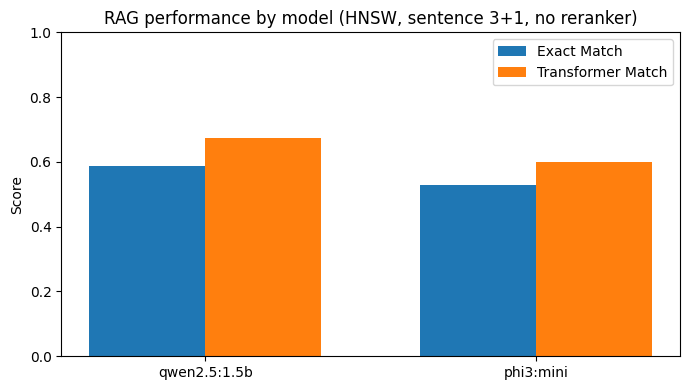

In [15]:
# Overall comparison
plot_df = overall_summary.copy()

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(plot_df))
width = 0.35

ax.bar(x - width/2, plot_df["exact_match"], width, label="Exact Match")
ax.bar(x + width/2, plot_df["transformer_match"], width, label="Transformer Match")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("RAG performance by model (HNSW, sentence 3+1, no reranker)")
ax.legend()
plt.tight_layout()
plt.show()


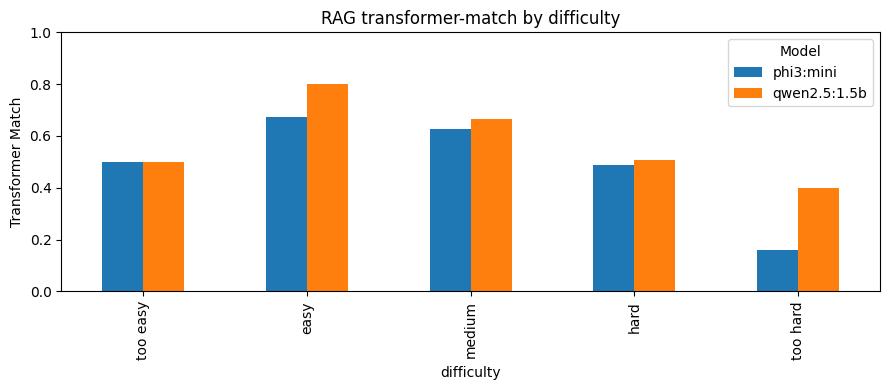

In [19]:
# Difficulty-stratified transformer match
plot_df = difficulty_summary.copy()
plot_df["difficulty"] = plot_df["difficulty"].fillna("unlabeled")

difficulty_order = ["too easy", "easy", "medium", "hard", "too hard", "unlabeled"]

pivot_df = (
    plot_df.pivot(index="difficulty", columns="model", values="transformer_match")
    .reindex([d for d in difficulty_order if d in plot_df["difficulty"].unique()])
)

fig, ax = plt.subplots(figsize=(9, 4))
pivot_df.plot(kind="bar", ax=ax)

ax.set_ylim(0, 1)
ax.set_ylabel("Transformer Match")
ax.set_title("RAG transformer-match by difficulty")
ax.legend(title="Model")
plt.tight_layout()
plt.show()

## Inspect a few examples

This helps check whether score differences come from retrieval misses, generation errors, or answer-formatting differences.


In [17]:
display(
    all_results[
        ["model", "difficulty", "question", "gold_answer", "generated_answer", "exact_match", "transformer_match"]
    ].head(20)
)


,model,difficulty,question,gold_answer,generated_answer,exact_match,transformer_match
0,qwen2.5:1.5b,easy,Was Abraham Lincoln the sixteenth President of...,yes,"Yes, Abraham Lincoln was indeed the sixteenth ...",1.0,1.0
1,qwen2.5:1.5b,easy,Was Abraham Lincoln the sixteenth President of...,Yes.,"Yes, Abraham Lincoln was indeed the sixteenth ...",1.0,1.0
2,qwen2.5:1.5b,medium,Did Lincoln sign the National Banking Act of 1...,yes,No context,0.0,0.0
3,qwen2.5:1.5b,easy,Did Lincoln sign the National Banking Act of 1...,Yes.,No context,0.0,0.0
4,qwen2.5:1.5b,medium,Did his mother die of pneumonia?,no,No context.,1.0,1.0
5,qwen2.5:1.5b,easy,Did his mother die of pneumonia?,No.,No context.,1.0,1.0
6,qwen2.5:1.5b,easy,How many long was Lincoln's formal education?,18 months,Lincoln's formal education consisted of about ...,1.0,1.0
7,qwen2.5:1.5b,medium,How many long was Lincoln's formal education?,18 months.,The context states that Lincoln's formal educa...,1.0,1.0
8,qwen2.5:1.5b,easy,When did Lincoln begin his political career?,1832,Young Abraham Lincoln began his political care...,1.0,1.0
9,qwen2.5:1.5b,medium,When did Lincoln begin his political career?,1832.,Young Abraham Lincoln began his political care...,1.0,1.0
